In [52]:
import numpy as np
import pandas as pd
import seaborn as sns

### 1. Linear Regression with Gradient Descent

In [44]:
class LinearRegression:
    def __init__(self, learning_rate=0.01, n_iter=1000):
        self.bias = None
        self.weights = None
        self.lr = learning_rate
        self.n_iter = n_iter

    def fit(self, X, y):
        # Step 1: Initialize theta(Q)
        m, n = X.shape # (no. of samples, no. of features)
        self.bias = 0
        self.weights = np.zeros(n)

        # Gradient Descent
        for i in range(self.n_iter):
            # Step 2: y_pred = bias + X.Q
            y_pred = self.bias + np.dot(X, self.weights);
    
            # Step 3: Calculate Derivatives - y_pred
            db = (1/m) * np.sum(y_pred - y)
            dw = (1/m) * np.dot(X.T, (y_pred - y))
    
            # Step 4: Convergence Theorem - update parameters
            self.bias -= self.lr * db
            self.weights -= self.lr * dw

    def predict(self, X):
        y_pred = self.bias + np.dot(X, self.weights)
        return y_pred;

In [45]:
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([2, 4, 6, 8, 10])

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

print(y_pred)
print("Bias:", model.bias)
print("Weights:", model.weights)
# It should be close to [y = 0 + 2x]

[2.06850809 4.04226297 6.01601785 7.98977273 9.96352761]
Bias: 0.09475321533750963
Weights: [1.97375488]


### 2. Linear Regression with OLS

In [46]:
class LinearRegressionOLS:
    def __init__(self, learning_rate=0.01, n_iter=1000):
        self.bias = None
        self.weights = None

    def fit(self, X, y):
        m, n = X.shape
        X = np.c_[np.ones((m, 1)), X]

        theta = np.dot(np.linalg.inv(np.dot(X.T, X)), np.dot(X.T, y))

        self.bias = theta[0]
        self.weights = theta[1:]

    def predict(self, X):
        y_pred = self.bias + np.dot(X, self.weights)
        return y_pred;

In [47]:
model = LinearRegressionOLS()
model.fit(X, y)
y_pred = model.predict(X)

print(y_pred)
print("Bias:", model.bias)
print("Weights:", model.weights)

[ 2.  4.  6.  8. 10.]
Bias: 3.219646771412954e-15
Weights: [2.]


#### LR with GD Vs LR with OLS
- Large dataset | Small dataset
- Many features | Less features
- Faster (m.n)  | Slower (n^3) {inverse_calculation}

### 3. Logistic Regression

In [48]:
class LogisticRegression:
    def __init__(self, learning_rate=0.1, n_iter=1000):
        self.bias = None
        self.weights = None
        self.lr = learning_rate
        self.n_iter = n_iter

    def _sigmoid(self, z):
        return (1 / (1 + np.exp(-z)))

    def fit(self, X, y):
        m, n = X.shape
        self.bias = 0
        self.weights = np.zeros(n)
        for i in range(self.n_iter):
            z = self.bias + np.dot(X, self.weights)
            y_pred = self._sigmoid(z)
            
            db = (1/m) * (y_pred - y)
            dw = (1/m) * np.dot(X.T, (y_pred - y))
            
            self.bias -= self.lr * db
            self.weights -= self.weights * dw

    def get_probabilities(self, X):
        z = self.bias + np.dot(X, self.weights)
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        probabilities = self.get_probabilities(X)
        y_pred = probabilities >= threshold
        return y_pred.astype(int)

In [49]:
X = np.array([[1,2], [2,3], [3,4], [4,5]])
y = np.array([0, 0, 1, 1])

model = LogisticRegression()
model.fit(X, y)
model.predict(X)

array([0, 0, 1, 1])

### 4. kNN Classifier

In [58]:
class kNNClassifier:
    def __init__(self, k=3):
        self.k = k

    def _euclidean_dist(self, x1, x2):
        return np.sqrt(np.sum((x1-x2)**2))
        
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        
    def _predictOne(self, x):
        distance = [self._euclidean_dist(x, x_train) for x_train in self.X_train]
        knn_indices = np.argsort(distance)[:self.k]
        knn_classes = self.y_train[knn_indices]
        majority_class = np.argmax(np.bincount(knn_classes))
        return majority_class

    def predict(self, X):
        y_pred = [self._predictOne(x) for x in X]
        return np.array(y_pred)

[0 1]


<Axes: xlabel='x1', ylabel='x2'>

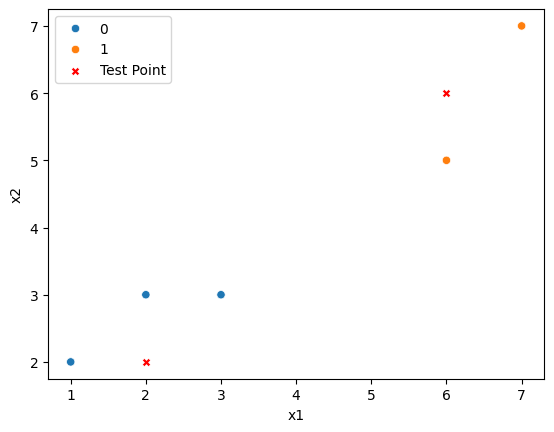

In [59]:
# Data
X_train = np.array([[1,2], [2,3], [3,3], [6,5], [7,7]])
y_train = np.array([0, 0, 0, 1, 1])
X_test = np.array([[2,2], [6,6]])

# Predict
model = kNNClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(y_pred)

# Plot
X_train_df = pd.DataFrame(X_train, columns=["x1", "x2"])
X_train_df["label"] = y_train
X_test_df = pd.DataFrame(X_test, columns=["x1", "x2"])
sns.scatterplot(data=X_train_df, x="x1", y="x2", hue="label")
sns.scatterplot(data=X_test_df, x="x1", y="x2", color="red", marker="X", label="Test Point")

### 5. kNN Regressor

In [65]:
class kNNRegressor:
    def __init__(self, k=3):
        self.k = k

    def _euclidean_dist(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))
        
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        
    def _predictOne(self, x):
        distances = [self._euclidean_dist(x, x_train) for x_train in self.X_train]
        knn_indices = np.argsort(distances)[:self.k]
        knn_values = self.y_train[knn_indices]
        return np.mean(knn_values)

    def predict(self, X):
        y_pred = [self._predictOne(x) for x in X]
        return np.array(y_pred)

[4. 6. 8.]


<Axes: xlabel='X', ylabel='y'>

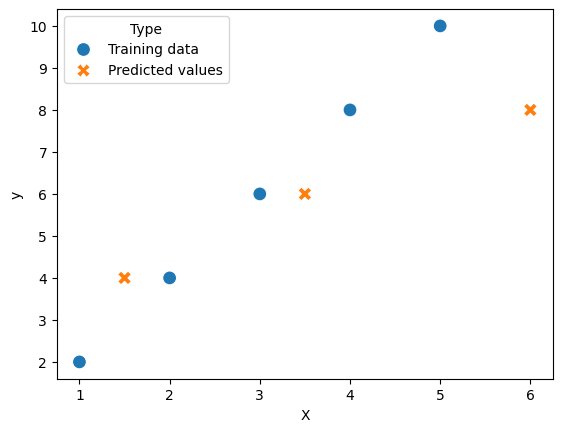

In [67]:
# Data
X_train = np.array([[1], [2], [3], [4], [5]])
y_train = np.array([2, 4, 6, 8, 10])
X_test = np.array([[1.5], [3.5], [6]])

# Predict
model = kNNRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(y_pred)

# Plot
train_df = pd.DataFrame({"X": X_train.ravel(), "y": y_train, "Type": "Training data"})
pred_df = pd.DataFrame({"X": X_test.ravel(), "y": y_pred, "Type": "Predicted values"})
plot_df = pd.concat([train_df, pred_df], ignore_index=True)

# Scatter plot
sns.scatterplot(
    data=plot_df,
    x="X",
    y="y",
    hue="Type",
    style="Type",
    s=100
)